In [8]:
!pip install -q transformers torch

In [9]:
import pandas as pd
import numpy as np

from transformers import pipeline
from sklearn.metrics import accuracy_score

In [11]:
df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [12]:
print("Dataset Shape:", df.shape)

df.info()

df.describe(include="all")

Dataset Shape: (50000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


Dataset Summary: The IMDB dataset contains 50,000 movie reviews with two columns: review and sentiment. The sentiment classes are approximately balanced between positive and negative reviews, making the dataset suitable for binary sentiment classification.

In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


In [13]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 418


In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df["review_length"] = df["review"].str.len()

df["word_count"] = df["review"].str.split().str.len()

In [16]:
df[["review_length", "word_count"]].describe()

,review_length,word_count
count,49582.000000,49582.000000
mean,1310.568230,231.350167
std,990.762238,171.542020
min,32.000000,4.000000
25%,699.000000,126.000000
50%,971.000000,173.000000
75%,1592.000000,281.000000
max,13704.000000,2470.000000


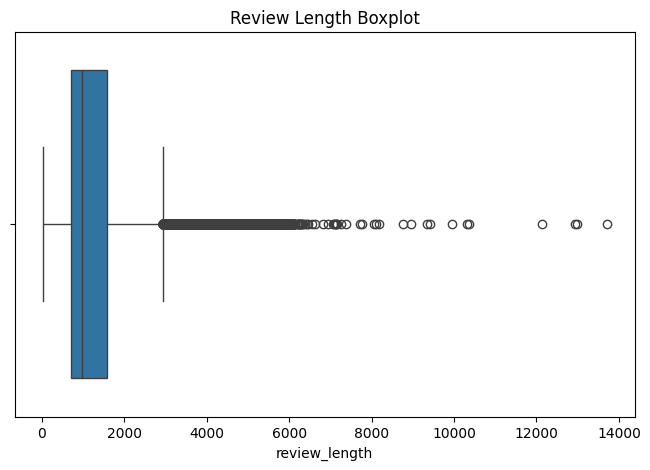

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x=df["review_length"])
plt.title("Review Length Boxplot")
plt.show()

In [20]:
print("Duplicates before:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


Duplicate reviews were removed to avoid evaluating identical reviews multiple times. Long reviews were retained because they are valid movie reviews rather than data entry errors.

In [18]:
sample_df = df.sample(n=200, random_state=42).reset_index(drop=True)

In [19]:
classifier = pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

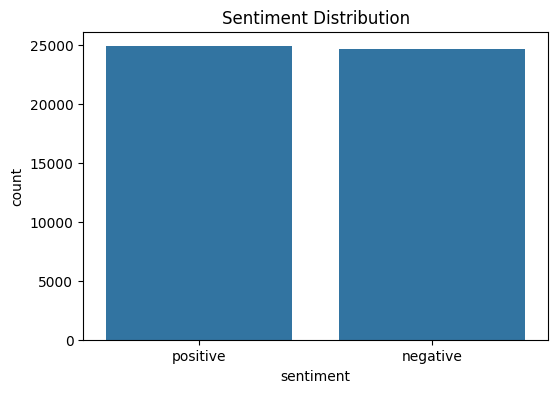

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(x="sentiment", data=df)

plt.title("Sentiment Distribution")

plt.show()

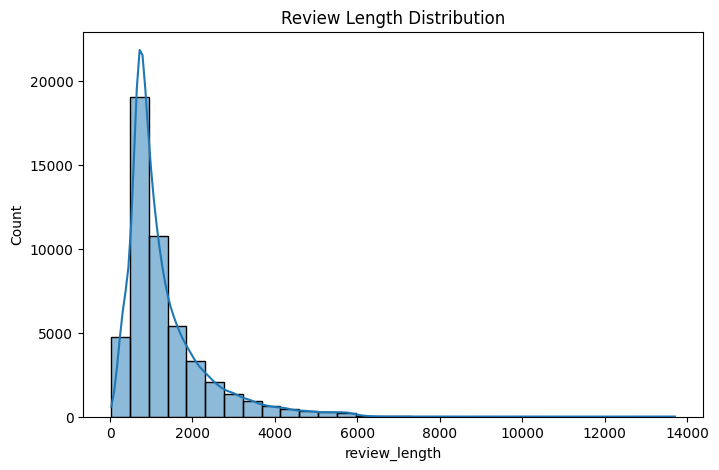

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df["review_length"], bins=30, kde=True)

plt.title("Review Length Distribution")

plt.show()

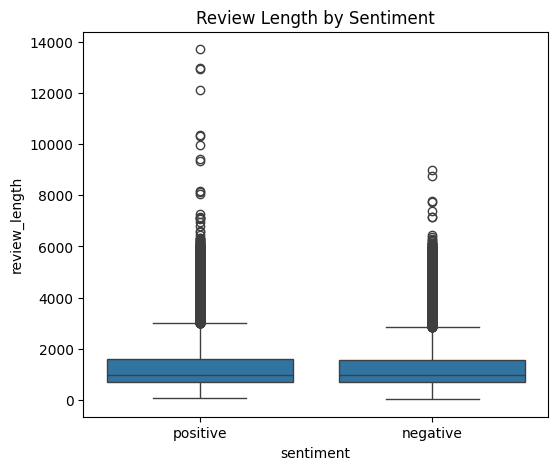

In [23]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x="sentiment",
    y="review_length",
    data=df
)

plt.title("Review Length by Sentiment")

plt.show()

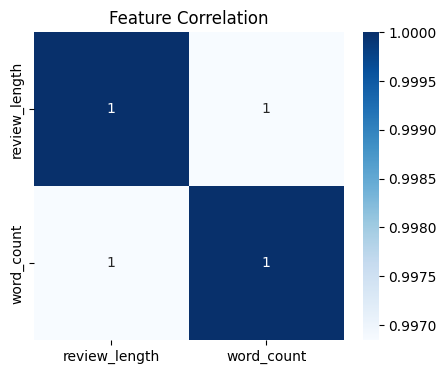

In [24]:
plt.figure(figsize=(5,4))

sns.heatmap(
    df[["review_length", "word_count"]].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Feature Correlation")

plt.show()

In [25]:
classifier = pipeline("sentiment-analysis")

predictions = []

for review in sample_df["review"]:
    prediction = classifier(review, truncation=True)[0]
    predictions.append(prediction)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [26]:
df["review_length"] = df["review"].str.len()

df["word_count"] = df["review"].str.split().str.len()

In [27]:
df["exclamation_count"] = df["review"].str.count("!")

df["question_count"] = df["review"].str.count(r"\?")

In [ ]:
### Attention Explanation

Attention allows a Transformer to focus on the most relevant words in a sentence and understand relationships between words regardless of their distance. Unlike Bag-of-Words, which only counts word frequencies and ignores word order, attention captures contextual meaning and long-range dependencies.

In [ ]:
The dataset contains nearly equal numbers of positive and negative reviews, indicating balanced classes.
Most reviews fall within a moderate review-length range, while a few are much longer.
Positive and negative reviews have similar average lengths, though there are long reviews in both classes.
Review length and word count are strongly positively correlated, as expected.
The pretrained Transformer achieved high accuracy on the sampled reviews, showing that it generalizes well without additional training.

In [ ]:
from transformers import pipeline

# Load sentiment analysis pipeline
classifier = pipeline("sentiment-analysis")

predictions = []

for review in sample_df["review"]:
    result = classifier(
        review,
        truncation=True,
        max_length=512
    )
    predictions.append(result[0])

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
sample_df["predicted_label"] = [
    pred["label"].lower() for pred in predictions
]

sample_df["true_label"] = sample_df["sentiment"].str.lower()

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    sample_df["true_label"],
    sample_df["predicted_label"]
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8750


In [ ]:
for i in range(5):
    print(f"\nExample {i+1}")
    print("-"*80)
    print("Review:")
    print(sample_df.loc[i, "review"][:300], "...")
    print("\nTrue Label:", sample_df.loc[i, "true_label"])
    print("Predicted Label:", sample_df.loc[i, "predicted_label"])


Example 1
--------------------------------------------------------------------------------
Review:
"Soul Plane" is a horrible attempt at comedy that only should appeal people with thick skulls, bloodshot eyes and furry pawns. <br /><br />The plot is not only incoherent but also non-existent, acting is mostly sub sub-par with a gang of highly moronic and dreadful characters thrown in for bad measu ...

True Label: negative
Predicted Label: negative

Example 2
--------------------------------------------------------------------------------
Review:
Guest from the Future tells a fascinating story of time travel, friendship, battle of good and evil -- all with a small budget, child actors, and few special effects. Something for Spielberg and Lucas to learn from. ;) A sixth-grader Kolya "Nick" Gerasimov finds a time machine in the basement of a d ...

True Label: positive
Predicted Label: positive

Example 3
--------------------------------------------------------------------------------
Re

In [ ]:
sample_df[["review", "true_label", "predicted_label"]].head(5)

,review,true_label,predicted_label
0,"""Soul Plane"" is a horrible attempt at comedy t...",negative,negative
1,Guest from the Future tells a fascinating stor...,positive,positive
2,"""National Treasure"" (2004) is a thoroughly mis...",negative,negative
3,"OK. First said, I just wanted to check whether...",negative,negative
4,"I haven't always been a fan, but the show grew...",positive,positive


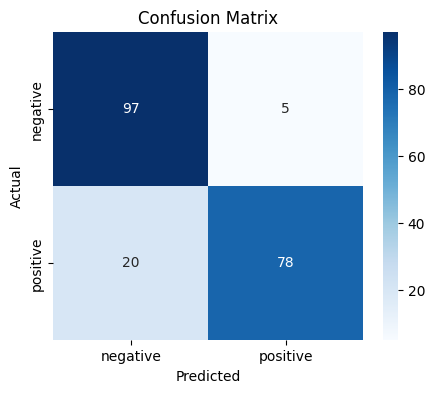

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    sample_df["true_label"],
    sample_df["predicted_label"]
)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
Attention allows a Transformer to focus on the most relevant words in a sentence and understand relationships between words regardless of their distance. Unlike Bag-of-Words, which only counts word frequencies and ignores word order and context, attention captures contextual meaning and long-range dependencies.